# Evaluation without leakage

Compare identical observations; tune hyperparameters on separate validation fields. Field RMSE requires reference truth, while held-out sensor errors can be computed without a dense truth map. Training residual alone rewards overfitting. Multiple independent fields and layouts reveal variability.

**Objective:** run a controlled multi-seed comparison with held-out sensors.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


IDW mean [field RMSE, held-out sensor RMSE] [0.12687607 0.13464669] std [0.00724359 0.01962285]
L2 mean [field RMSE, held-out sensor RMSE] [0.10383104 0.11409283] std [0.01582106 0.03295394]
GP mean [field RMSE, held-out sensor RMSE] [0.14350752 0.12661832] std [0.02981095 0.03498637]


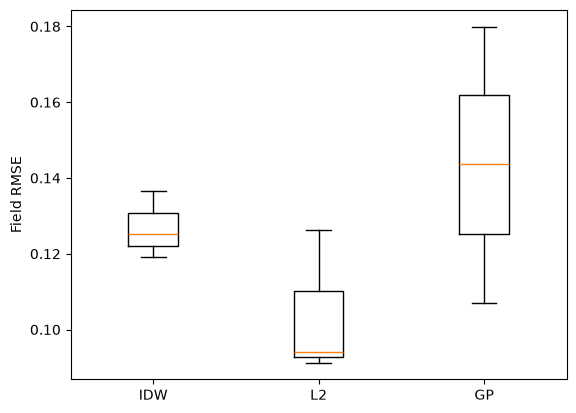

In [2]:
grid=Grid((12,12)); rows=[]
for seed in range(3):
    truth=simulate(grid,10000+seed,kind='front'); rng=np.random.default_rng(11000+seed)
    p=rng.uniform(0,1,(30,2)); A=points(grid,p); y=observe(A,truth,.03,12000+seed)
    H=points(grid,rng.uniform(0,1,(20,2))); hy=observe(H,truth,.03,13000+seed)
    estimators={'IDW':idw(grid,p,y),'L2':tikhonov(grid,A,y),'GP':gaussian_process(grid,A,y)}
    for name,r in estimators.items(): rows.append((name,np.sqrt(np.mean((r.mean-truth)**2)),np.sqrt(np.mean((H@r.mean.ravel()-hy)**2))))
for name in estimators:
    values=np.array([row[1:] for row in rows if row[0]==name]); print(name,'mean [field RMSE, held-out sensor RMSE]',values.mean(0),'std',values.std(0))
fig,ax=plt.subplots(); ax.boxplot([[r[1] for r in rows if r[0]==name] for name in estimators],tick_labels=list(estimators)); ax.set_ylabel('Field RMSE'); plt.show()


**Exercise:** expand to all seven models, maintain identical measurement budgets, and train neural models only once on separate training fields. Report training time, inference time, uncertainty coverage, and an out-of-distribution front or new geometry. Explain where your experiment lacks statistical power.

See [theory notes](../docs/theory.md) for assumptions and equations.